<a href="https://colab.research.google.com/github/sivakrishnaps/AI-ML-session/blob/main/mnist_using_cnn_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification of Handwritten digits in MNIST dataset through CNN

This is a Keras implementation of a CNN neural network model. More details about keras API is available in the documentation <https://keras.io/getting-started/sequential-model-guide/>

> The MLP code shown below solves a binary classification problem.

> This script also prints Area Under Curve (AUC) and plots a Receiver Operating Characteristic (ROC) curve at the end.

>**Step 1:** First, import all the Python modules.
From Keras, import the Sequential model as well as the Dense, Dropout and the Activation layers. Also import roc_curve and auc from sklearn.

In [ ]:
# loading libraries
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Importing both TensorFlow and its high level API - Keras.
import tensorflow as tf
from tensorflow import keras
# Setting the random seeds for repeatability
tf.random.set_seed(1)
np.random.seed(42)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Conv2D, BatchNormalization,MaxPooling2D, Flatten
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.optimizers import RMSprop
import matplotlib.pyplot as plt

## Loading dataset and split for training and testing

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of X_train:  (60000, 28, 28)
Shape of X_test:  (10000, 28, 28)


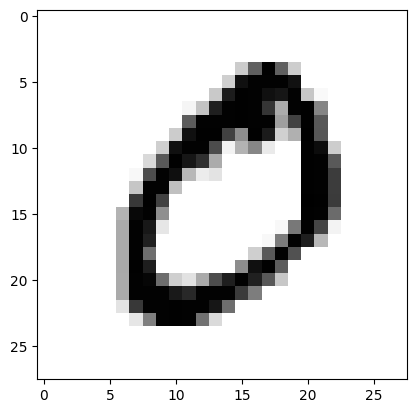

In [ ]:
# Load MNIST database of handwritten digits
mnistDB = keras.datasets.mnist
# Training Dataset of 60,000 28x28 grayscale images of the 10 digits,
# along with a test set of 10,000 images.
(X_train, y_train),(X_test, y_test) = mnistDB.load_data()
print("Shape of X_train: ", X_train.shape)
# Shape of X_train:  (60000, 28, 28)
print("Shape of X_test: ", X_test.shape)
# Shape of X_test:  (10000, 28, 28)
# We can view the dataset with matplotlib
plt.imshow(X_train[1], cmap='binary')
plt.show()

> **Data pre-processing for CNN**:  DNN accepts only 1-Dimensional data as input,
 but the MNIST dataset is a -2 Dimensional image. A CNN network can accept 2-D data. These 2D images should be directly feed them as input to CNN.  All 60000 training images are kept in 2-D representation.

> reshaping pixel array for train and test data.

In [ ]:
X_train = X_train.reshape((60000, 28,28,1))
X_test = X_test.reshape((10000, 28,28,1))

>**Normalizing pixel values**:  The grayscale image pixels are unsigned values between 0 and 255. These pixels need to be normalized to the range 0 to 1 for DNN.  So, the entire training data is converted to 32-bit float and then divided with 255 to bring down the range to 0 to 1. Similar operations are done to 10000 testing images.



# Check again the shape of both training and testing dataset.

In [ ]:
# Scale pixel values to range 0 to 1.
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

In [ ]:
print("Shape of X_train: ", X_train.shape)
# Shape of X_train:  (60000, 28,28,1)
print("Shape of X_test: ", X_test.shape)
# Shape of X_test:  (10000, 28,28,1)

Shape of X_train:  (60000, 28, 28, 1)
Shape of X_test:  (10000, 28, 28, 1)


>**Step 2**: Below is the Python module that initializes the neural network.
It comprises a Sequential model that has A block of convolutional and maxpooling  sparse layers, where each layer is followed by an Activation layer.
Note that I used Dropout layer only after the convolution layers. The convolution layer followed with a flatten layer and further a Deep Neural net.
The first two Activation layers in the DNN block have ‘relu’ as the activation function.
For the last Activation layer, I used ‘softmax’ because it is a multi class classification problem.
I used Stochastic Gradient Descent with Nesterov momentum for training.
Typically, ‘categorical_crossentropy’ is used for multi class classification problems.

In [ ]:
num_classes=10
model = Sequential()
model.add(Conv2D(32,(3,3), activation="relu", input_shape=X_train.shape[1:]))
model.add(MaxPooling2D((2,2)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation="relu"))
# Here begins the fully connected part (DNN) of ConvNet
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.1))
model.add(Dense(32, activation="relu"))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,466 (372.91 KB)

 Trainable params: 95,274 (372.16 KB)

 Non-trainable params: 192 (768.00 B)

>**Step 3:** Generate the Neural Network

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
#optimizer=RMSprop() also can be used

## Visualizing the model

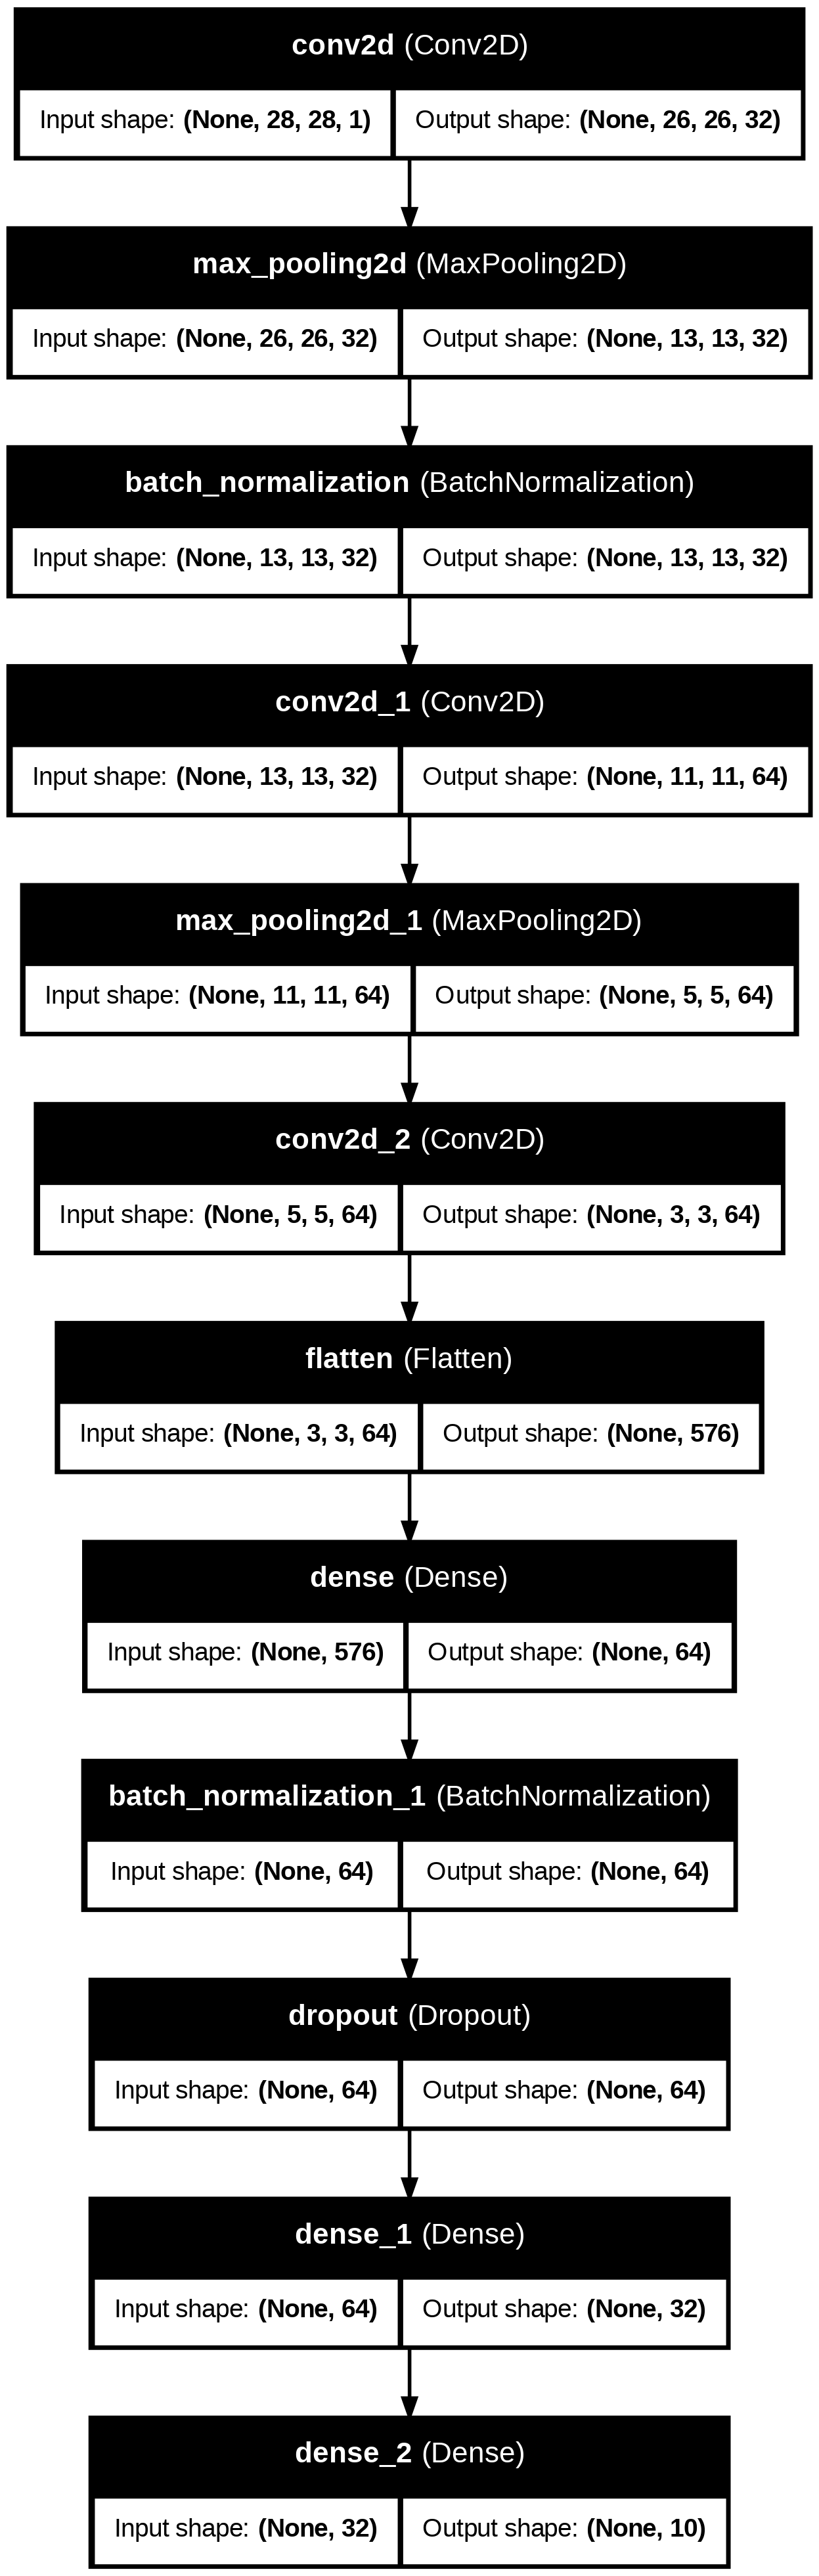

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png',show_shapes=True, show_layer_names=True)

>**Step 4:**  Conversion of target set to categorical variables

In [ ]:
# Generate dummy data and fix hyper parameters
batch_size = 128
num_classes = 10
epochs = 20


# convert class vectors to binary class matrices
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

>**Step 5:**  Train the model

In [ ]:
cb_early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss',
                                                  patience=10,
                                                  restore_best_weights=True)
cb_model_checkpoint = keras.callbacks.ModelCheckpoint("bestModel_MNIST.h5",
                                                      save_best_only=True)
history = model.fit(x=X_train, y=y_train, validation_split=0.1, epochs=10,
batch_size=16,callbacks=[cb_early_stopping,cb_model_checkpoint])

Epoch 1/10
3372/3375 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9088 - loss: 0.3189

3375/3375 ━━━━━━━━━━━━━━━━━━━━ 77s 22ms/step - accuracy: 0.9536 - loss: 0.1598 - val_accuracy: 0.9813 - val_loss: 0.0577
Epoch 2/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 78s 20ms/step - accuracy: 0.9795 - loss: 0.0665 - val_accuracy: 0.9797 - val_loss: 0.0650
Epoch 3/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9845 - loss: 0.0504

3375/3375 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.9838 - loss: 0.0531 - val_accuracy: 0.9873 - val_loss: 0.0464
Epoch 4/10
3373/3375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9877 - loss: 0.0392

3375/3375 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.9882 - loss: 0.0389 - val_accuracy: 0.9892 - val_loss: 0.0397
Epoch 5/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 81s 20ms/step - accuracy: 0.9903 - loss: 0.0306 - val_accuracy: 0.9873 - val_loss: 0.0574
Epoch 6/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.9927 - loss: 0.0232 - val_accuracy: 0.9905 - val_loss: 0.0492
Epoch 7/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 82s 20ms/step - accuracy: 0.9941 - loss: 0.0189 - val_accuracy: 0.9905 - val_loss: 0.0481
Epoch 8/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.9944 - loss: 0.0175 - val_accuracy: 0.9887 - val_loss: 0.0491
Epoch 9/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 68s 20ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9898 - val_loss: 0.0521
Epoch 10/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 82s 20ms/step - accuracy: 0.9957 - loss: 0.0130 - val_accuracy: 0.9910 - val_loss: 0.0423


## Displaying the learning of the network

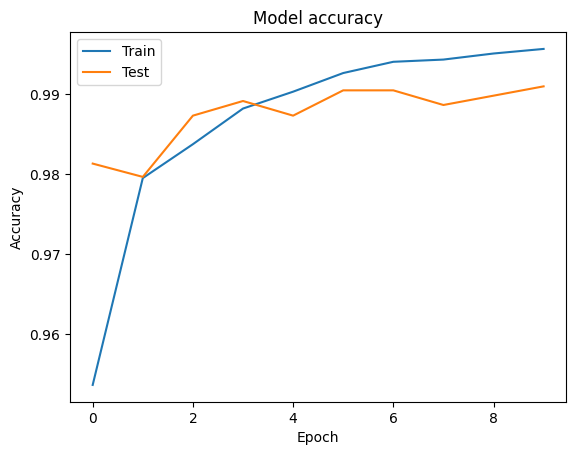

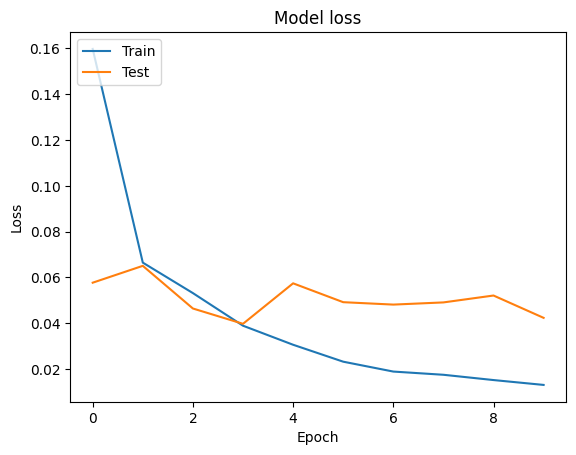

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

>**Step 6:** Evaluate the model on test set and print the error and accuracy scores

In [ ]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.030194293707609177
Test accuracy: 0.9908000230789185


In [ ]:
y_pred = model.predict(X_test)
#y_pred=y_pred>0.5
from sklearn.metrics import confusion_matrix
y_pred=np.argmax(y_pred, axis=1)
#print(y_pred)
#y_pred.shape
y_temp=y_test>0.5
y_temp=np.argmax(y_temp,axis=1)
cm = confusion_matrix(y_true = y_temp, y_pred=y_pred)
print(cm)
#y_temp.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step
[[ 975    1    1    0    1    0    1    1    0    0]
 [   0 1133    1    0    0    0    0    1    0    0]
 [   0    0 1026    0    0    0    0    5    0    1]
 [   0    0    3 1003    0    3    0    0    1    0]
 [   0    0    0    0  979    0    0    1    0    2]
 [   0    0    0   10    0  879    1    0    1    1]
 [   5    3    4    0    6    1  938    0    1    0]
 [   0    2    1    0    0    0    0 1024    0    1]
 [   2    0    2    1    3    0    1    0  962    3]
 [   2    1    0    0    9    2    0    6    0  989]]
